In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


patients_path = '/media/Volume/data/MIMIC_IV/patients.csv.gz'
discharge_path = '/media/Volume/data/MIMIC_IV/discharge.csv.gz'
admissions_path = '/media/Volume/data/MIMIC_IV/admissions.csv.gz'
exams_path = '/media/Volume/data/MIMIC_IV/exams_filtered.csv'
out_path = '/media/Volume/data/MIMIC_IV/exams_cox_labels.csv'
icu_stays_path = '/media/Volume/data/MIMIC_IV/icustays.csv.gz'
dat_path = '/media/Volume/data/MIMIC_IV/record_list.csv'
machine_measurement_path = '/media/Volume/data/MIMIC_IV/machine_measurements.csv'
notes_path = '/media/Volume/data/MIMIC_IV/waveform_note_links.csv'

code_15_exams = '/media/Volume/data/CODE15/processed/exams_filtered.csv'

In [29]:
code_15 = pd.read_csv(code_15_exams)
# drop unnamed 0 and unnamed 1
code_15 = code_15.loc[:, ~code_15.columns.str.contains('^Unnamed')]
# print columns
print(code_15.columns)
# remove null timey and death
code_15 = code_15[code_15['timey'].notna()]
code_15.head(n=10)

Index(['exam_id', 'age', 'is_male', 'nn_predicted_age', '1dAVb', 'RBBB',
       'LBBB', 'SB', 'ST', 'AF', 'patient_id', 'death', 'timey', 'normal_ecg',
       'trace_file', 'r_peaks', 'r_peak_interval_mean', 'r_peak_variance',
       'valid'],
      dtype='object')


,exam_id,age,is_male,nn_predicted_age,1dAVb,RBBB,LBBB,SB,ST,AF,patient_id,death,timey,normal_ecg,trace_file,r_peaks,r_peak_interval_mean,r_peak_variance,valid
0,1169160,38,True,40.160484,False,False,False,False,False,False,523632,False,2.098628,True,exams_part13.hdf5,[ 57 285 507 742 972 1196 1419 1630 1848 ...,0.625309,0.020557,True
1,2873686,73,True,67.059440,False,False,False,False,False,False,1724173,False,6.657529,False,exams_part13.hdf5,[ 219 460 702 944 1176 1404 1631 1859 2080],0.646181,0.020969,True
2,168405,67,True,79.621740,False,False,False,False,False,True,51421,False,4.282188,False,exams_part13.hdf5,[ 220 532 716 1024 1200 1599 1874],0.765741,0.214907,True
3,271011,41,True,69.750260,False,False,False,False,False,False,1737282,False,4.038353,True,exams_part13.hdf5,[ 306 585 868 1142 1434 1725 2004 2290 2595 ...,0.795679,0.024149,True
4,384368,73,True,78.873460,False,False,False,False,False,False,331652,False,3.786298,False,exams_part13.hdf5,[ 115 285 454 623 793 962 1132 1303 1474 ...,0.473090,0.002729,True
6,1467619,33,False,48.628563,False,False,False,False,False,False,1351337,False,1.498629,False,exams_part13.hdf5,[ 271 623 969 1303 1629 1971 2313 2660],0.948016,0.022455,True
7,1537328,24,True,29.179337,False,False,False,False,False,False,1519774,False,1.367122,True,exams_part13.hdf5,[ 224 465 702 985 1259 1497 1744 2012 2269 ...,0.692222,0.054459,True
8,981735,82,True,82.224610,False,False,False,False,False,False,1192754,False,2.468491,False,exams_part13.hdf5,[ 160 432 684 925 1152 1377 1604 1838 2108 ...,0.716111,0.097054,True
10,1237983,81,False,80.735916,False,False,False,False,False,False,485601,False,1.978081,False,exams_part13.hdf5,[ 123 356 587 820 1054 1283 1512 1744 1976],0.643403,0.004799,True
11,2854912,63,True,41.023660,False,False,False,False,False,False,1594408,False,5.778077,False,exams_part13.hdf5,[ 93 454 822 1020],0.858333,0.218169,True


/home/luna97/Research/MIT-BIH_ecg_arrhytmia/mit_bih_env/lib/python3.11/site-packages/lifelines/utils/__init__.py:1185: UserWarning: Attempting to convert an unexpected datatype 'object' to float. Suggestion: 1) use `lifelines.utils.datetimes_to_durations` to do conversions or 2) manually convert to floats/booleans.
  warnings.warn(warning_text, UserWarning)


<Axes: xlabel='timeline'>

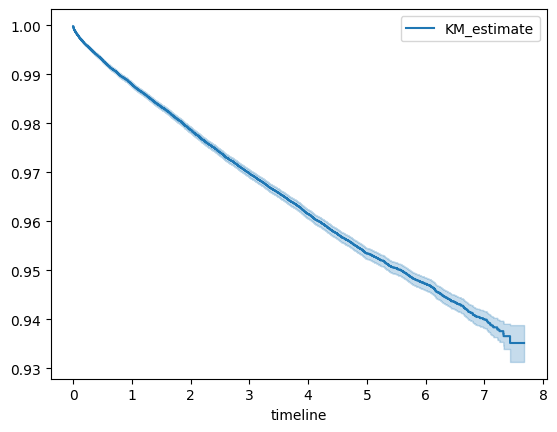

In [107]:
from lifelines import KaplanMeierFitter
kmf = KaplanMeierFitter()
kmf.fit(durations=code_15['timey'], event_observed=code_15['death'])
kmf.plot_survival_function()

In [141]:
dat_record = pd.read_csv(dat_path)
dat_record

,subject_id,study_id,file_name,ecg_time,path
0,10000032,40689238,40689238,2180-07-23 08:44:00,files/p1000/p10000032/s40689238/40689238
1,10000032,44458630,44458630,2180-07-23 09:54:00,files/p1000/p10000032/s44458630/44458630
2,10000032,49036311,49036311,2180-08-06 09:07:00,files/p1000/p10000032/s49036311/49036311
3,10000117,45090959,45090959,2181-03-04 17:14:00,files/p1000/p10000117/s45090959/45090959
4,10000117,48446569,48446569,2183-09-18 13:52:00,files/p1000/p10000117/s48446569/48446569
...,...,...,...,...,...
800030,19999840,48683947,48683947,2164-09-12 12:28:00,files/p1999/p19999840/s48683947/48683947
800031,19999840,41842293,41842293,2164-09-17 11:31:00,files/p1999/p19999840/s41842293/41842293
800032,19999987,41190887,41190887,2145-11-02 19:54:00,files/p1999/p19999987/s41190887/41190887
800033,19999987,45828463,45828463,2145-11-03 03:00:00,files/p1999/p19999987/s45828463/45828463


In [143]:
ecgs = pd.read_csv(exams_path)
print(ecgs.columns)

# keep columns we need
ecgs = ecgs[['subject_id', 'study_id', 'ecg_time', 'dod', 'anchor_year', 'anchor_age', 'fold', 'strat_fold', 'file_name']]
ecgs['dod'] = pd.to_datetime(ecgs['dod'], errors='coerce').dt.date
ecgs['ecg_time'] = pd.to_datetime(ecgs['ecg_time'], errors='coerce')
ecgs['ecg_date'] = ecgs['ecg_time'].dt.date
ecgs.head(n=5)

Index(['Unnamed: 0', 'file_name', 'study_id', 'subject_id', 'ecg_time',
       'ed_stay_id', 'ed_hadm_id', 'hosp_hadm_id', 'ed_diag_ed',
       'ed_diag_hosp', 'hosp_diag_hosp', 'all_diag_hosp', 'all_diag_all',
       'gender', 'age', 'anchor_year', 'anchor_age', 'dod',
       'ecg_no_within_stay', 'ecg_taken_in_ed', 'ecg_taken_in_hosp',
       'ecg_taken_in_ed_or_hosp', 'fold', 'strat_fold'],
      dtype='object')


,subject_id,study_id,ecg_time,dod,anchor_year,anchor_age,fold,strat_fold,file_name,ecg_date
0,10000032,40689238,2180-07-23 08:44:00,2180-09-09,2180.0,52.0,17,9,files/p1000/p10000032/s40689238/40689238,2180-07-23
1,10000032,44458630,2180-07-23 09:54:00,2180-09-09,2180.0,52.0,17,9,files/p1000/p10000032/s44458630/44458630,2180-07-23
2,10000032,49036311,2180-08-06 09:07:00,2180-09-09,2180.0,52.0,17,9,files/p1000/p10000032/s49036311/49036311,2180-08-06
3,10000117,45090959,2181-03-04 17:14:00,NaT,2174.0,48.0,18,0,files/p1000/p10000117/s45090959/45090959,2181-03-04
4,10000117,48446569,2183-09-18 13:52:00,NaT,2174.0,48.0,18,0,files/p1000/p10000117/s48446569/48446569,2183-09-18


In [156]:
patients = pd.read_csv(patients_path)
patients['dod'] = pd.to_datetime(patients['dod']).dt.date
patients

,subject_id,gender,anchor_age,anchor_year,anchor_year_group,dod
0,10000032,F,52,2180,2014 - 2016,2180-09-09
1,10000048,F,23,2126,2008 - 2010,NaT
2,10000058,F,33,2168,2020 - 2022,NaT
3,10000068,F,19,2160,2008 - 2010,NaT
4,10000084,M,72,2160,2017 - 2019,2161-02-13
...,...,...,...,...,...,...
364622,19999828,F,46,2147,2017 - 2019,NaT
364623,19999829,F,28,2186,2008 - 2010,NaT
364624,19999840,M,58,2164,2008 - 2010,2164-09-17
364625,19999914,F,49,2158,2017 - 2019,NaT


In [112]:
dat_hosp = pd.read_csv(admissions_path)[["subject_id", "hadm_id", "admittime", "dischtime", "deathtime"]]
dat_hosp['admittime'] = pd.to_datetime(dat_hosp['admittime'], errors='coerce')
dat_hosp['dischtime'] = pd.to_datetime(dat_hosp['dischtime'], errors='coerce')
dat_hosp['deathtime'] = pd.to_datetime(dat_hosp['deathtime'], errors='coerce')
dat_hosp

,subject_id,hadm_id,admittime,dischtime,deathtime
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaT
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaT
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaT
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaT
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaT
...,...,...,...,...,...
546023,19999828,25744818,2149-01-08 16:44:00,2149-01-18 17:00:00,NaT
546024,19999828,29734428,2147-07-18 16:23:00,2147-08-04 18:10:00,NaT
546025,19999840,21033226,2164-09-10 13:47:00,2164-09-17 13:42:00,2164-09-17 13:42:00
546026,19999840,26071774,2164-07-25 00:27:00,2164-07-28 12:15:00,NaT


In [166]:
max_disch_time = dat_hosp.sort_values(["subject_id",'dischtime']).groupby("subject_id").last().reset_index()
max_disch_time = max_disch_time[['subject_id', 'dischtime']]
max_disch_time.rename(columns={'dischtime': 'max_disch_time'}, inplace=True)
max_disch_time = max_disch_time.reset_index()
max_disch_time

,index,subject_id,max_disch_time
0,0,10000032,2180-08-07 17:50:00
1,1,10000068,2160-03-04 06:26:00
2,2,10000084,2160-12-28 16:07:00
3,3,10000108,2163-09-28 09:04:00
4,4,10000117,2183-09-21 16:30:00
...,...,...,...
223447,223447,19999733,2152-07-09 03:45:00
223448,223448,19999784,2124-03-29 13:16:00
223449,223449,19999828,2149-01-18 17:00:00
223450,223450,19999840,2164-09-17 13:42:00


In [167]:
max_ecg_time = ecgs.sort_values(by=['subject_id', 'ecg_time']).groupby('subject_id').last().reset_index()
max_ecg_time = max_ecg_time[['subject_id', 'ecg_time']]
max_ecg_time.rename(columns={'ecg_time': 'max_ecg_time'}, inplace=True)
max_ecg_time

,subject_id,max_ecg_time
0,10000032,2180-08-06 09:07:00
1,10000117,2183-09-18 13:52:00
2,10000285,2159-11-26 14:29:00
3,10000560,2198-09-19 10:01:00
4,10000635,2139-01-22 14:09:00
...,...,...
160851,19999733,2152-07-08 21:38:00
160852,19999784,2119-07-25 05:58:00
160853,19999828,2147-07-29 11:59:00
160854,19999840,2164-09-17 11:31:00


In [168]:
min_ecg_time = ecgs.sort_values(by=['subject_id', 'ecg_time']).groupby('subject_id').first().reset_index()
min_ecg_time = min_ecg_time[['subject_id', 'ecg_time']]
min_ecg_time.rename(columns={'ecg_time': 'min_ecg_time'}, inplace=True)
min_ecg_time

,subject_id,min_ecg_time
0,10000032,2180-07-23 08:44:00
1,10000117,2181-03-04 17:14:00
2,10000285,2159-11-26 14:29:00
3,10000560,2189-10-03 12:54:00
4,10000635,2136-06-19 07:24:00
...,...,...
160851,19999733,2152-07-08 21:38:00
160852,19999784,2119-06-18 17:52:00
160853,19999828,2147-07-29 11:59:00
160854,19999840,2164-07-24 22:31:00


In [169]:
max_ecg_patient = (max_ecg_time.loc[:, "max_ecg_time"] - min_ecg_time.loc[:, "min_ecg_time"]).argmax()
pd.merge(min_ecg_time, max_ecg_time, on="subject_id").iloc[max_ecg_patient, :]

subject_id                 12410764
min_ecg_time    2156-10-09 11:43:00
max_ecg_time    2167-09-06 12:44:00
Name: 38543, dtype: object

In [170]:
data = pd.merge(ecgs, max_disch_time, how="inner", on="subject_id")
data = pd.merge(data, max_ecg_time, how="inner", on="subject_id") 
data['death'] = data['dod'].notna()
data


,subject_id,study_id,ecg_time,dod,anchor_year,anchor_age,fold,strat_fold,file_name,ecg_date,index,max_disch_time,max_ecg_time,death
0,10000032,40689238,2180-07-23 08:44:00,2180-09-09,2180.0,52.0,17,9,files/p1000/p10000032/s40689238/40689238,2180-07-23,0,2180-08-07 17:50:00,2180-08-06 09:07:00,True
1,10000032,44458630,2180-07-23 09:54:00,2180-09-09,2180.0,52.0,17,9,files/p1000/p10000032/s44458630/44458630,2180-07-23,0,2180-08-07 17:50:00,2180-08-06 09:07:00,True
2,10000032,49036311,2180-08-06 09:07:00,2180-09-09,2180.0,52.0,17,9,files/p1000/p10000032/s49036311/49036311,2180-08-06,0,2180-08-07 17:50:00,2180-08-06 09:07:00,True
3,10000117,45090959,2181-03-04 17:14:00,NaT,2174.0,48.0,18,0,files/p1000/p10000117/s45090959/45090959,2181-03-04,4,2183-09-21 16:30:00,2183-09-18 13:52:00,False
4,10000117,48446569,2183-09-18 13:52:00,NaT,2174.0,48.0,18,0,files/p1000/p10000117/s48446569/48446569,2183-09-18,4,2183-09-21 16:30:00,2183-09-18 13:52:00,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
736121,19999840,48683947,2164-09-12 12:28:00,2164-09-17,2164.0,58.0,18,11,files/p1999/p19999840/s48683947/48683947,2164-09-12,223450,2164-09-17 13:42:00,2164-09-17 11:31:00,True
736122,19999840,41842293,2164-09-17 11:31:00,2164-09-17,2164.0,58.0,18,11,files/p1999/p19999840/s41842293/41842293,2164-09-17,223450,2164-09-17 13:42:00,2164-09-17 11:31:00,True
736123,19999987,41190887,2145-11-02 19:54:00,NaT,2145.0,57.0,15,15,files/p1999/p19999987/s41190887/41190887,2145-11-02,223451,2145-11-11 12:57:00,2145-11-03 08:47:00,False
736124,19999987,45828463,2145-11-03 03:00:00,NaT,2145.0,57.0,15,15,files/p1999/p19999987/s45828463/45828463,2145-11-03,223451,2145-11-11 12:57:00,2145-11-03 08:47:00,False


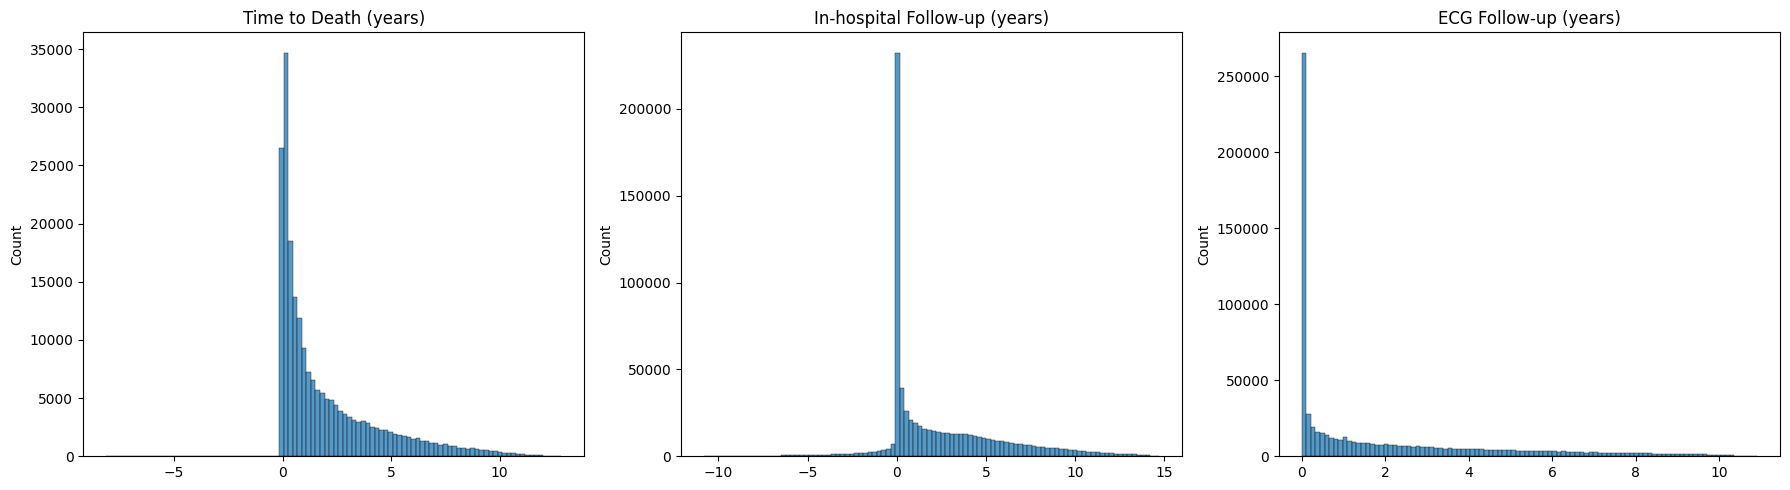

In [197]:
ecg_followup = data['max_ecg_time'] - data['ecg_time']
inhosp_followup = data['max_disch_time'] - data['ecg_time']
timey = (data['dod'] - data['ecg_date'])

tmp_timey = [t.days/365 for t in timey if not pd.isna(t)]
tmp_inhosp = [t.days/365 for t in inhosp_followup if not pd.isna(t)]
tmp_ecg = [t.days/365 for t in ecg_followup if not pd.isna(t)]

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(tmp_timey, bins=100, ax=axs[0])
axs[0].set_title('Time to Death (years)')
sns.histplot(tmp_inhosp, bins=100, ax=axs[1])
axs[1].set_title('In-hospital Follow-up (years)')
sns.histplot(tmp_ecg, bins=100, ax=axs[2])
axs[2].set_title('ECG Follow-up (years)')
plt.tight_layout()


/tmp/ipykernel_847236/2015110302.py:7: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  final_data['timey'] = final_data['timey'].fillna(final_data['last_known_date'].dt.date - final_data['ecg_date'])


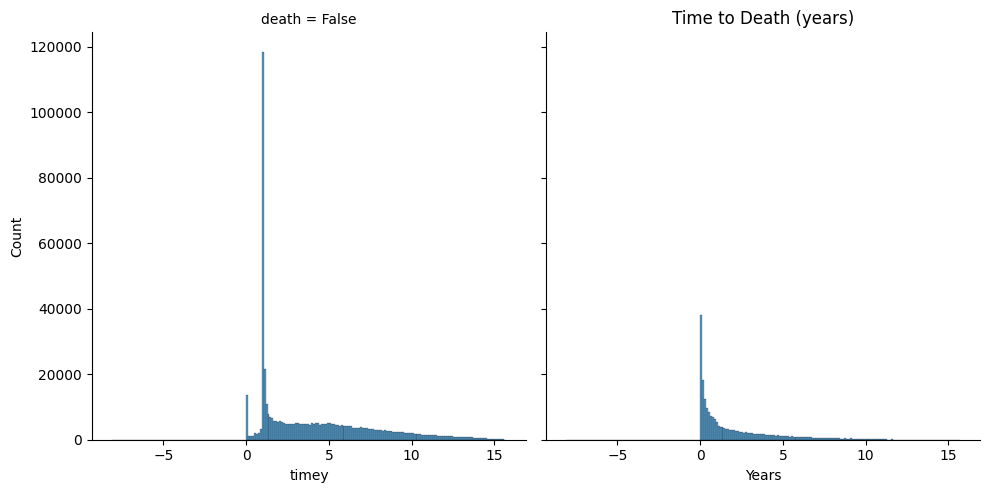

In [218]:
final_data = data.copy()
final_data['last_known_date'] = final_data['max_disch_time'] + pd.Timedelta(days=365)
mask = final_data['last_known_date'] < final_data['max_ecg_time']
final_data.loc[mask, 'last_known_date'] = final_data.loc[mask, 'max_ecg_time']
final_data['timey'] = timey

final_data['timey'] = final_data['timey'].fillna(final_data['last_known_date'].dt.date - final_data['ecg_date'])
final_data['timey'] = final_data['timey'].dt.days / 365.25  # Convert to years

# remove where i do not have ecgs
final_data = final_data[final_data['ecg_time'].notna()]

# plot the dist of timey
sns.displot(final_data, x='timey', bins=200, col='death')
plt.title('Time to Death (years)')
plt.xlabel('Years')
plt.ylabel('Frequency')
plt.show()


12.837782340862423


<Axes: xlabel='timeline'>

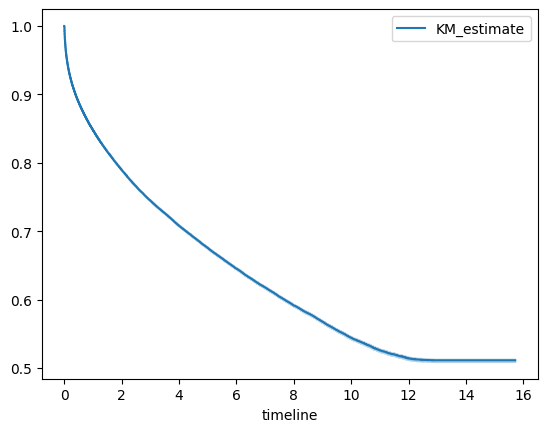

In [233]:
kmf_mimic = KaplanMeierFitter()
longest_timey_died = final_data[final_data['death'] == True]['timey'].max()
print(f'{longest_timey_died}')
filtered = final_data[(final_data['timey'].notna()) & (final_data['timey'] > 0)]
kmf_mimic.fit(durations=filtered['timey'], event_observed=filtered['death'])
kmf_mimic.plot_survival_function()

In [224]:
final_data.loc[final_data['timey'] == longest_timey_died]

,subject_id,study_id,ecg_time,dod,anchor_year,anchor_age,fold,strat_fold,file_name,ecg_date,index,max_disch_time,max_ecg_time,death,last_known_date,timey
62300,10873928,48049089,2166-03-13 10:28:00,NaT,2169.0,82.0,7,3,files/p1087/p10873928/s48049089/48049089,2166-03-13,19154,2178-01-13 13:45:00,2172-02-07 12:00:00,False,2179-01-13 13:45:00,12.837782
77434,11083023,49040083,2157-06-01 16:43:00,NaT,2157.0,79.0,13,2,files/p1108/p11083023/s49040083/49040083,2157-06-01,23767,2169-04-03 16:30:00,2161-10-06 20:07:00,False,2170-04-03 16:30:00,12.837782
133596,11832245,44842968,2141-04-21 07:44:00,NaT,2138.0,58.0,0,17,files/p1183/p11832245/s44842968/44842968,2141-04-21,40689,2153-02-21 17:15:00,2149-05-03 11:50:00,False,2154-02-21 17:15:00,12.837782
156534,12139817,45830385,2155-06-25 03:05:00,NaT,2155.0,59.0,18,0,files/p1213/p12139817/s45830385/45830385,2155-06-25,47491,2167-04-27 17:50:00,2163-07-31 20:39:00,False,2168-04-26 17:50:00,12.837782
237678,13242574,44509381,2146-11-12 16:01:00,NaT,2146.0,53.0,16,7,files/p1324/p13242574/s44509381/44509381,2146-11-12,72098,2158-09-14 15:20:00,2155-03-14 12:51:00,False,2159-09-14 15:20:00,12.837782
237679,13242574,44530328,2146-11-12 17:04:00,NaT,2146.0,53.0,16,7,files/p1324/p13242574/s44530328/44530328,2146-11-12,72098,2158-09-14 15:20:00,2155-03-14 12:51:00,False,2159-09-14 15:20:00,12.837782
237680,13242574,47741373,2146-11-12 20:55:00,NaT,2146.0,53.0,16,7,files/p1324/p13242574/s47741373/47741373,2146-11-12,72098,2158-09-14 15:20:00,2155-03-14 12:51:00,False,2159-09-14 15:20:00,12.837782
263627,13591121,46880250,2158-08-26 10:11:00,NaT,2165.0,76.0,18,8,files/p1359/p13591121/s46880250/46880250,2158-08-26,79734,2170-06-28 18:18:00,2168-04-02 04:36:00,False,2171-06-28 18:18:00,12.837782
339282,14606194,40686570,2151-11-20 16:19:00,NaT,2151.0,49.0,19,19,files/p1460/p14606194/s40686570/40686570,2151-11-20,102370,2163-09-22 16:06:00,2161-01-29 13:59:00,False,2164-09-21 16:06:00,12.837782
339283,14606194,45980609,2151-11-20 16:34:00,NaT,2151.0,49.0,19,19,files/p1460/p14606194/s45980609/45980609,2151-11-20,102370,2163-09-22 16:06:00,2161-01-29 13:59:00,False,2164-09-21 16:06:00,12.837782


In [ ]:
# -*- coding: utf-8 -*-
"""
Written by Mingxuan Liu
(minor modifications: PVL)
# 09/12/24 discharge time no longer records admit time (only affects multimodal)
# 01/14/25 TTE is no longer (max ECG + 365) if (max ECG) > max(Discharge+365)
# ... instead is max(Discharge+365, max_ECG)
"""

# %% Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime 
from datetime import datetime, timedelta
import os

# from tableone import TableOne

# %% Data paths


patients_path = '/media/Volume/data/MIMIC_IV/patients.csv.gz'
discharge_path = '/media/Volume/data/MIMIC_IV/discharge.csv.gz'
admissions_path = '/media/Volume/data/MIMIC_IV/admissions.csv.gz'
exams_path = '/media/Volume/data/MIMIC_IV/exams_filtered.csv'
out_path = '/media/Volume/data/MIMIC_IV/exams_cox_labels.csv'
icu_stays_path = '/media/Volume/data/MIMIC_IV/icustays.csv.gz'  
dat_path = '/media/Volume/data/MIMIC_IV/record_list.csv'
machine_measurement_path = '/media/Volume/data/MIMIC_IV/machine_measurements.csv'
machine_measurement_data_dict = '/media/Volume/data/MIMIC_IV/machine_measurements_data_dictionary.csv'
notes_path = '/media/Volume/data/MIMIC_IV/waveform_note_links.csv'

# patient_csv_dir = "/lab-share/CHIP-Lacava-e2/Public/physionet.org/files/mimiciv/2.2/hosp/patients.csv.gz"
patient_csv_dir = patients_path

# admission_csv_dir = "/lab-share/CHIP-Lacava-e2/Public/physionet.org/files/mimiciv/2.2/hosp/admissions.csv.gz"
admission_csv_dir = admissions_path

# dat_ecg = pd.read_csv("/lab-share/CHIP-Lacava-e2/Public/physionet.org/files/mimic-iv-ecg/1.0/machine_measurements.csv")
dat_ecg = pd.read_csv(machine_measurement_path)

# dat_record = pd.read_csv("/lab-share/CHIP-Lacava-e2/Public/physionet.org/files/mimic-iv-ecg/1.0/record_list.csv")
dat_record = pd.read_csv(dat_path)


# %% Extract DoD from patients table
dat_dod = pd.read_csv(patient_csv_dir)

print(f"#patients in patients table: {len(dat_dod.subject_id.unique())}")

dat_dod['dod'] = pd.to_datetime(dat_dod['dod'], errors='coerce')  # Convert to datetime, handle errors
# dat_dod["dod"] = [datetime.strptime(t, "%Y-%m-%d") if not pd.isna(t) else t for t in dat_dod["dod"]]
print(dat_dod.head())
#patients in patients table: 299712

# %% extract the max dischtime from each patient from admissions table
dat_hosp = pd.read_csv(admission_csv_dir)[["subject_id", "hadm_id", "admittime","dischtime", "deathtime"]]
print(dat_hosp.head())
print(f"#patients in hospotal table: {len(dat_hosp.subject_id.unique())}")


# dat_hosp["admittime"] = [datetime.strptime(t, "%Y-%m-%d %H:%M:%S") for t in dat_hosp["admittime"]] # added PVL 07 29 24
dat_hosp["admittime"] = pd.to_datetime(dat_hosp["admittime"], errors='coerce')  # Convert to datetime, handle errors
dat_hosp["dischtime"] = pd.to_datetime(dat_hosp["dischtime"], errors='coerce')  # Convert to datetime, handle errors

# max_disch_time = dat_hosp.groupby("subject_id").apply(lambda x: max(x.dischtime)).to_frame() # Include_Groups arg is deprecated PVL 6/12/24
max_disch_time = dat_hosp.sort_values(["subject_id",'dischtime']).groupby("subject_id").last().reset_index()
max_disch_time = max_disch_time[['subject_id', 'dischtime']]
max_disch_time.rename(columns={'dischtime': 'max_disch_time'}, inplace=True)
max_disch_time = max_disch_time.reset_index()

# %% ecg table with machine measurements
# ecg_dir = "/lab-share/CHIP-Lacava-e2/Public/physionet.org/files/mimic-iv-ecg/1.0"

print(dat_ecg.shape)
print(f"#patients in ecg table: {len(dat_ecg.subject_id.unique())}")
dat_ecg.head()

# dat_ecg["ecg_time"] = [datetime.strptime(t, "%Y-%m-%d %H:%M:%S") for t in dat_ecg["ecg_time"]]
dat_ecg['ecg_time'] = pd.to_datetime(dat_ecg['ecg_time'], errors='coerce')  # Convert to datetime, handle errors
dat_ecg['ecg_date'] = dat_ecg['ecg_time'].dt.date
# dat_ecg["ecg_date"] = [t.strftime("%Y-%m-%d") for t in dat_ecg["ecg_time"]]

# %% use ecg time from the records
# max_ecg_time = dat_record.groupby("subject_id").apply(lambda x: max(x.ecg_time)).to_frame() # Include_Groups arg is deprecated PVL 6/12/24
max_ecg_time = dat_record.sort_values(by=['subject_id', 'ecg_time']).groupby('subject_id').last().reset_index()
max_ecg_time.rename(columns={'ecg_time': 'max_ecg_time'}, inplace=True)
max_ecg_time = max_ecg_time[['subject_id', 'max_ecg_time']]
max_ecg_time = max_ecg_time.reset_index()
print(max_ecg_time)

dat = pd.merge(dat_ecg, dat_record, on=["subject_id", "study_id"])
# dat = pd.read_csv(exams_path)
dat = dat.rename(columns={"ecg_time_y":"ecg_time", "ecg_date_y":"ecg_date"})
print(dat.shape)

dat = pd.merge(dat, dat_dod, how="inner", on="subject_id")
dat = pd.merge(dat, max_ecg_time, how="left", on="subject_id")
dat['ecg_time'] = pd.to_datetime(dat['ecg_time'], errors='coerce')  # Convert to datetime, handle errors
print(len(dat.subject_id.unique()))
dat = pd.merge(dat, max_disch_time, how="left", on="subject_id")
dat['max_disch_time'] = pd.to_datetime(dat['max_disch_time'], errors='coerce')  # Convert to datetime, handle errors
dat['max_ecg_time'] = pd.to_datetime(dat['max_ecg_time'], errors='coerce')  # Convert to datetime, handle errors
# print(len(dat.subject_id.unique()))
# dat = pd.merge(dat, dat_hosp, how="left", on="subject_id")
print(dat.shape)
print(len(dat.subject_id.unique()))
print(dat.head())

# dat.to_csv(os.path.join(os.getcwd(), 'MIMIC IV', "machine_measurements_with_dod.csv"))

print(dat.columns)

# %% add event and time-to-event to "machine_measurements_with_dod.csv"
dat["event"] = ~pd.isna(dat["dod"])
print(dat['ecg_time'])
print(dat['max_ecg_time'])

# note: patients who are survival according to dod may lack of the records about max disch time, 
# or the max_disch_time is far earlier than the ecg time, thus using max_ecg_time instead. 
# From MIMIC-IV website: "If the individual survived for at least one year after their last hospital 
# discharge, then the dod column will have a NULL value."

# note from the document of "mimic-iv-ecg" (the User notes section): "the ECG time stamps
#  could be significantly out of sync with the corresponding time stamps in the MIMIC-IV 
#  Clinical Database, MIMIC-IV Waveform Database, or other modules in MIMIC-IV. An additional 
#  limitation, as noted above, is that some of the ECGs provided here were collected outside of
#  the ED and ICU. This means that the timestamps for those ECGs won't overlap with data from 
#  the MIMIC-IV Clinical Database."  

/tmp/ipykernel_847236/848875376.py:41: DtypeWarning: Columns (16,17,18,19,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  dat_ecg = pd.read_csv(machine_measurement_path)


#patients in patients table: 364627
   subject_id gender  anchor_age  anchor_year anchor_year_group        dod
0    10000032      F          52         2180       2014 - 2016 2180-09-09
1    10000048      F          23         2126       2008 - 2010        NaT
2    10000058      F          33         2168       2020 - 2022        NaT
3    10000068      F          19         2160       2008 - 2010        NaT
4    10000084      M          72         2160       2017 - 2019 2161-02-13
   subject_id   hadm_id            admittime            dischtime deathtime
0    10000032  22595853  2180-05-06 22:23:00  2180-05-07 17:15:00       NaN
1    10000032  22841357  2180-06-26 18:27:00  2180-06-27 18:49:00       NaN
2    10000032  25742920  2180-08-05 23:44:00  2180-08-07 17:50:00       NaN
3    10000032  29079034  2180-07-23 12:35:00  2180-07-25 17:55:00       NaN
4    10000068  25022803  2160-03-03 23:16:00  2160-03-04 06:26:00       NaN
#patients in hospotal table: 223452
(800035, 33)
#patients

/tmp/ipykernel_847236/1187319511.py:3: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dat['time_to_event'] = dat['time_to_event'].fillna(dat["max_disch_time"].dt.date - dat["ecg_time"].dt.date + timedelta(days=365))


the maximum time-to-event in year is: 157.26027397260273


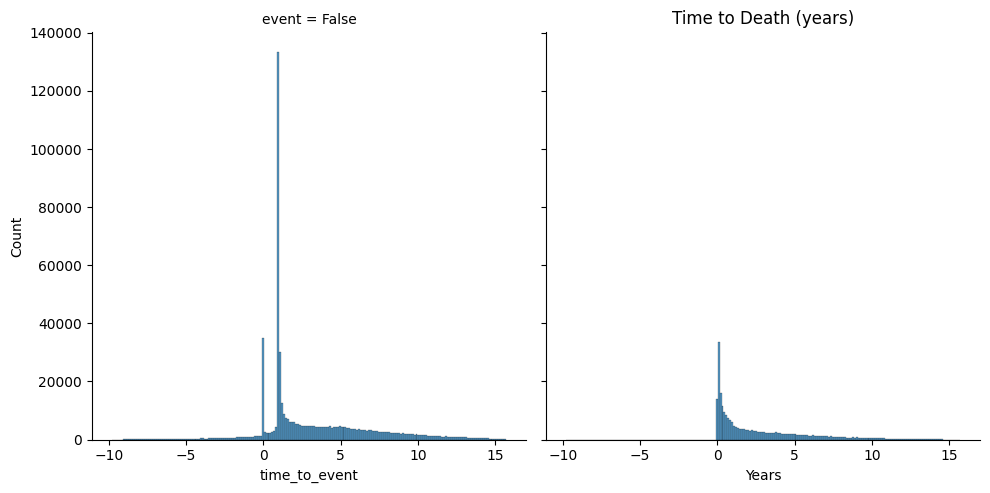

In [284]:
dat['dod'] = pd.to_datetime(dat['dod'], errors='coerce')  # Convert to datetime, handle errors
dat["time_to_event"] = dat['dod'].dt.date - dat["ecg_time"].dt.date
dat['time_to_event'] = dat['time_to_event'].fillna(dat["max_disch_time"].dt.date - dat["ecg_time"].dt.date + timedelta(days=365))
dat['time_to_event'] = dat['time_to_event'].fillna(dat["max_ecg_time"].dt.date - dat["ecg_time"].dt.date)

# prev:
# dat["time_to_event"] = [dat.loc[i, "max_disch_time"] - dat.loc[i, "ecg_time"] + timedelta(days=365) if pd.isna(dat.loc[i, "dod"]) else dod_followup[i] for i in range(dat.shape[0])] 
# dat["time_to_event"] = [dat["max_ecg_time"][i] - dat["ecg_time"][i] + timedelta(days=365) if pd.isna(dat["time_to_event"][i]) or dat["time_to_event"][i].days < 0 else dat["time_to_event"][i] for i in range(dat.shape[0])] 
# dat["time_to_event"] = [t.days for t in dat["time_to_event"]]

print(f"the maximum time-to-event in year is: {(dat['time_to_event'].dt.total_seconds() / (365 * 360 * 24)).max()}")
dat['time_to_event'] = dat['time_to_event'].dt.days / 365

# plot the dist of timey
sns.displot(dat, x='time_to_event', bins=200, col='event')
plt.title('Time to Death (years)')
plt.xlabel('Years')
plt.ylabel('Frequency')
plt.show()


In [294]:
dat.columns

Index(['subject_id', 'study_id', 'cart_id', 'ecg_time_x', 'report_0',
       'report_1', 'report_2', 'report_3', 'report_4', 'report_5', 'report_6',
       'report_7', 'report_8', 'report_9', 'report_10', 'report_11',
       'report_12', 'report_13', 'report_14', 'report_15', 'report_16',
       'report_17', 'bandwidth', 'filtering', 'rr_interval', 'p_onset',
       'p_end', 'qrs_onset', 'qrs_end', 't_end', 'p_axis', 'qrs_axis',
       't_axis', 'ecg_date', 'file_name', 'ecg_time', 'path', 'gender',
       'anchor_age', 'anchor_year', 'anchor_year_group', 'dod', 'index_x',
       'max_ecg_time', 'index_y', 'max_disch_time', 'event', 'time_to_event'],
      dtype='object')

/tmp/ipykernel_847236/161173429.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat_filtered['time_to_event'] = dat_filtered['time_to_event']


<Axes: xlabel='timeline'>

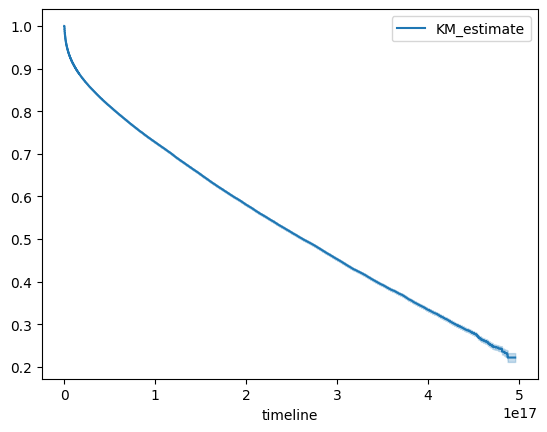

In [282]:
kmf_mimic = KaplanMeierFitter()
dat_filtered = dat[dat["time_to_event"].notna() & (dat["time_to_event"].dt.total_seconds() > 0)]
dat_filtered['time_to_event'] = dat_filtered['time_to_event'] 
kmf_mimic.fit(durations=dat_filtered["time_to_event"], event_observed=dat_filtered['dod'].notna())
kmf_mimic.plot_survival_function()

#patients in final_data: 130247
#patients in dat: 161332
Number of patients in final_data not in dat: 0
Number of patients in dat not in final_data: 31085


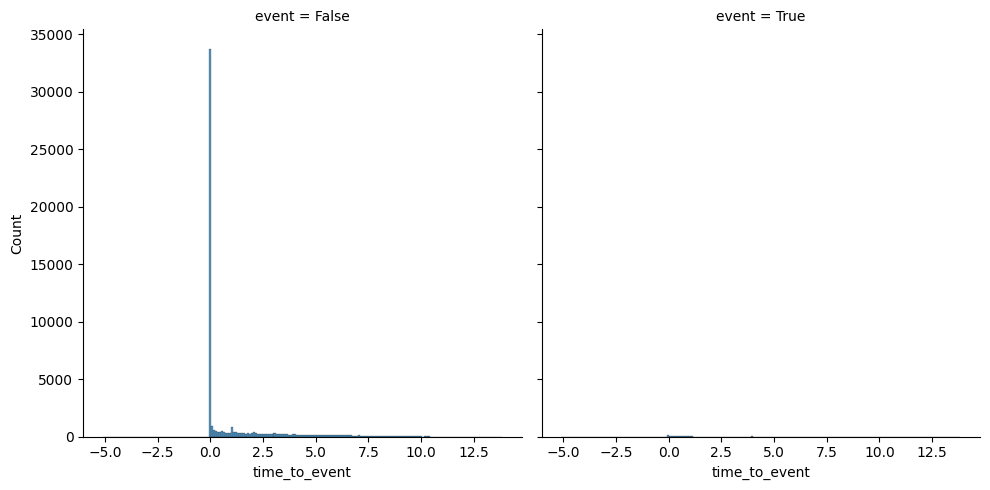

In [ ]:
patients_fd = final_data['subject_id'].unique()
print(f"#patients in final_data: {len(patients_fd)}")

patients_dat = dat['subject_id'].unique()
print(f"#patients in dat: {len(patients_dat)}")

print(f"Number of patients in final_data not in dat: {len(set(patients_fd) - set(patients_dat))}")
print(f"Number of patients in dat not in final_data: {len(set(patients_dat) - set(patients_fd))}")

outer_sub_ids = set(patients_dat) - set(patients_fd)
dat_outer = dat[dat['subject_id'].isin(outer_sub_ids)]

sns.displot(dat_outer, x='time_to_event', bins=200, col='event')

/tmp/ipykernel_847236/1406495754.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dat_filtered['time_to_event'] = dat_filtered['time_to_event']


<Axes: xlabel='timeline'>

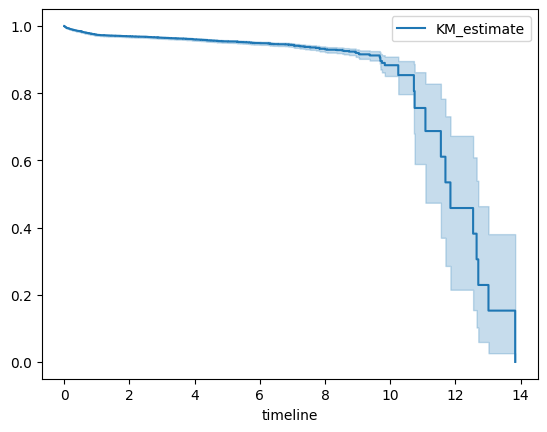

In [289]:
kmf_mimic = KaplanMeierFitter()
dat_filtered = dat_outer[dat_outer["time_to_event"].notna() & (dat_outer["time_to_event"] > 0)]
dat_filtered['time_to_event'] = dat_filtered['time_to_event'] 
kmf_mimic.fit(durations=dat_filtered["time_to_event"], event_observed=dat_filtered['dod'].notna())
kmf_mimic.plot_survival_function()

In [291]:
unique_patients_dat = dat_ecg['subject_id'].unique()
unique_patients_ecg = ecgs['subject_id'].unique()

print(f"#patients in ecgs: {len(unique_patients_ecg)}")
print(f"#patients in dat: {len(unique_patients_dat)}")
print(f'patients in ecgs not in dat: {len(set(unique_patients_ecg) - set(unique_patients_dat))}')
print(f'patients in dat not in ecgs: {len(set(unique_patients_dat) - set(unique_patients_ecg))}')

#patients in ecgs: 160856
#patients in dat: 161352
patients in ecgs not in dat: 0
patients in dat not in ecgs: 496


In [297]:
dat_record.head()

,subject_id,study_id,file_name,ecg_time,path
0,10000032,40689238,40689238,2180-07-23 08:44:00,files/p1000/p10000032/s40689238/40689238
1,10000032,44458630,44458630,2180-07-23 09:54:00,files/p1000/p10000032/s44458630/44458630
2,10000032,49036311,49036311,2180-08-06 09:07:00,files/p1000/p10000032/s49036311/49036311
3,10000117,45090959,45090959,2181-03-04 17:14:00,files/p1000/p10000117/s45090959/45090959
4,10000117,48446569,48446569,2183-09-18 13:52:00,files/p1000/p10000117/s48446569/48446569
